## Data preparation

* Check if the missing values are presented in the features.
* If there are missing values:
    * For categorical features, replace them with 'NA'
    * For numerical features, replace with with 0.0 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

In [3]:
from sklearn.model_selection import train_test_split

In [4]:
data = 'https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/course_lead_scoring_2026.csv'
!wget -nc $data

File ‘course_lead_scoring_2026.csv’ already there; not retrieving.



In [5]:
df = pd.read_csv('course_lead_scoring_2026.csv')

In [6]:
df.head()

,lead_source,industry,employment_status,location,annual_income,number_of_courses_viewed,interaction_count,lead_score,converted
0,organic_search,technology,employed,europe,88160.0,3,4,0.64,1
1,social_media,technology,employed,south_america,72688.0,3,7,0.72,1
2,referral,retail,employed,europe,44697.0,3,4,0.58,1
3,paid_ads,manufacturing,student,NaN,NaN,3,6,0.57,0
4,referral,manufacturing,student,north_america,24062.0,4,5,0.62,1


In [7]:
df.isnull().sum()

lead_source                 148
industry                    240
employment_status           194
location                    208
annual_income               369
number_of_courses_viewed      0
interaction_count             0
lead_score                   35
converted                     0
dtype: int64

In [8]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

categorical_columns = list(df.select_dtypes(include=['object', 'string']).columns)

for c in categorical_columns:
    df[c] = df[c].str.lower().str.replace(' ', '_')


In [9]:
categorical = ['lead_source', 
               'industry', 
               'employment_status', 
               'location']

numerical = ['annual_income', 
             'number_of_courses_viewed',
             'interaction_count', 
             'lead_score']

In [10]:
df[numerical] = df[numerical].fillna(0)
df[categorical] = df[categorical].fillna('NA')

In [11]:
df.isnull().sum()

lead_source                 0
industry                    0
employment_status           0
location                    0
annual_income               0
number_of_courses_viewed    0
interaction_count           0
lead_score                  0
converted                   0
dtype: int64

In [12]:
df.converted.value_counts()

converted
1    2883
0    2117
Name: count, dtype: int64

In [13]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

df_train.reset_index(drop=True)
df_val.reset_index(drop=True)
df_test.reset_index(drop=True)

y_train = df_train.converted.values
y_val = df_val.converted.values
y_test = df_test.converted.values

del df_train['converted']
del df_val['converted']
del df_test['converted']

df.shape, df_full_train.shape, df_train.shape, df_val.shape, df_test.shape

((5000, 9), (4000, 9), (3000, 8), (1000, 8), (1000, 8))

## Question 1
ROC AUC feature importance

ROC AUC could also be used to evaluate feature importance of numerical variables.

Let's do that

- For each numerical variable, use it as score (aka prediction) and compute the AUC with the y variable as ground truth.
- Use the training dataset for that

If your AUC is < 0.5, invert this variable by putting "-" in front

(e.g. -df_train['balance'])

AUC can go below 0.5 if the variable is negatively correlated with the target variable. You can change the direction of the correlation by negating this variable - then negative correlation becomes positive.

Which numerical variable (among the following 4) has the highest AUC?

- lead_score
- number_of_courses_viewed
- interaction_count
- annual_income

## Question 2: Training the model

Apply one-hot-encoding using DictVectorizer and train the logistic regression with these parameters:

LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)

What's the AUC of this model on the validation dataset? (round to 3 digits)

- 0.532
- 0.632
- 0.732
- 0.832

Answer
- 0.732


In [14]:
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression

In [15]:
dv = DictVectorizer(sparse=False)

dict_train = df_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(dict_train)

model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
model.fit(X_train, y_train)

,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'liblinear'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalt

In [16]:
dict_val = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(dict_val)

y_pred = model.predict_proba(X_val)[:,1]

In [17]:
from sklearn.metrics import roc_auc_score

In [18]:
auc = roc_auc_score(y_val, y_pred)
round(auc,3)

0.732

## Question 3: Precision and Recall

Now let's compute precision and recall for our model.
- Evaluate the model on all thresholds from 0.0 to 1.0 with step 0.01
- For each threshold, compute precision and recall
- Plot them

At which threshold precision and recall curves intersect? Ignore thresholds at which both metrics are zero, and choose the threshold with the smallest absolute difference between precision and recall.

- 0.43
- 0.63
- 0.73
- 0.83

Answer
- 0.63

In [19]:
threshold = np.arange(0.0, 1.0, 0.01)
threshold

array([0.  , 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ,
       0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21,
       0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32,
       0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43,
       0.44, 0.45, 0.46, 0.47, 0.48, 0.49, 0.5 , 0.51, 0.52, 0.53, 0.54,
       0.55, 0.56, 0.57, 0.58, 0.59, 0.6 , 0.61, 0.62, 0.63, 0.64, 0.65,
       0.66, 0.67, 0.68, 0.69, 0.7 , 0.71, 0.72, 0.73, 0.74, 0.75, 0.76,
       0.77, 0.78, 0.79, 0.8 , 0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87,
       0.88, 0.89, 0.9 , 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98,
       0.99])

In [20]:
from sklearn.metrics import roc_auc_score

In [21]:
roc_auc_score(y_val, y_pred)

0.7318222288173319

In [22]:
actual_positive = (y_val == 1)
actual_negative = (y_val == 0)

In [23]:
t= 0.5

pred_positive = (y_pred >= t)
pred_negative = (y_pred < t)

In [24]:
tp = (pred_positive & actual_positive).sum()
tn = (pred_negative & actual_negative).sum()
fp = (pred_positive & actual_negative).sum()
fn= (pred_negative & actual_positive).sum()

In [25]:
precision = tp / (tp + fp)
recall = tp / (tp + fn)

precision, recall

#recall is the same as total positive rate (TPR)

(np.float64(0.6436363636363637), np.float64(0.9061433447098977))

In [26]:
fpr = fp/(fp + tn) #false positive rate (FPR)

In [27]:
scores = []

for t in threshold:
     
    actual_positive = (y_val == 1)
    actual_negative = (y_val == 0)
    
    pred_positive = (y_pred >= t)
    pred_negative = (y_pred < t)
    
    tp = (pred_positive & actual_positive).sum()
    tn = (pred_negative & actual_negative).sum()
    fp = (pred_positive & actual_negative).sum()
    fn = (pred_negative & actual_positive).sum()
    
    scores.append((t, tp, tn, fp, fn))

In [28]:
columns = ['threshold', 'true_positive', 'true_negative', 'false_positive', 'false_negative']
df_scores = pd.DataFrame(scores, columns=columns)
df_scores.head()

,threshold,true_positive,true_negative,false_positive,false_negative
0,0.00,586,0,414,0
1,0.01,586,0,414,0
2,0.02,586,0,414,0
3,0.03,586,0,414,0
4,0.04,586,0,414,0


In [78]:
df_scores['precision'] = df_scores.true_positive/(df_scores.true_positive + df_scores.false_positive)
df_scores['recall'] = df_scores.true_positive/(df_scores.true_positive + df_scores.false_negative)

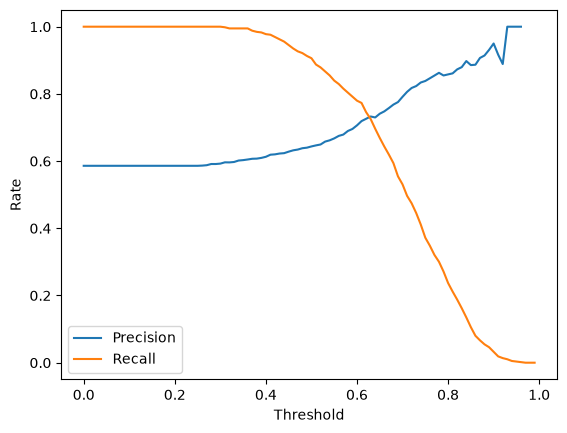

In [79]:
plt.plot(df_scores.threshold, df_scores.precision, label='Precision')
plt.plot(df_scores.threshold, df_scores.recall, label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Rate')
plt.legend()
plt.show()

## Question 4: F1 score
Precision and recall are conflicting - when one grows, the other goes down. That's why they are often combined into the F1 score - a metrics that takes into account both

This is the formula for computing F1:

F1
=
2
⋅
P
⋅
R
P
+
R

Where 
P
 is precision and 
R
 is recall.

Let's compute F1 for all thresholds from 0.0 to 1.0 with increment 0.01

At which threshold F1 is maximal?

- 0.21
- 0.41
- 0.61
- 0.81

Answer
- 

In [ ]:
df_scores.head()

,threshold,true_positive,true_negative,false_positive,false_negative,F1,precision,recall
0,0.00,586,0,414,0,0.752658,0.586,1.0
1,0.01,586,0,414,0,0.752658,0.586,1.0
2,0.02,586,0,414,0,0.752658,0.586,1.0
3,0.03,586,0,414,0,0.752658,0.586,1.0
4,0.04,586,0,414,0,0.752658,0.586,1.0


In [73]:
df_t = pd.DataFrame(scores)
df_t.head()

,0
0,0.752658


## Question 5: 5-Fold CV
Use the KFold class from Scikit-Learn to evaluate our model on 5 different folds:

KFold(n_splits=5, shuffle=True, random_state=1)

- Iterate over different folds of df_full_train
- Split the data into train and validation
- Train the model on train with these parameters: LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
- Use AUC to evaluate the model on validation

How large is standard deviation of the scores across different folds?

- 0.001
- 0.007
- 0.013
- 0.060

Answer
- 0.007


In [29]:
from sklearn.model_selection import KFold

In [30]:
kfold = KFold(n_splits=5, shuffle=True, random_state=1)

In [31]:
train_idx, val_idx = next(kfold.split(df_full_train))
len(df_full_train), len(train_idx), len(val_idx)

(4000, 3200, 800)

In [32]:
df_train = df_full_train.iloc[train_idx]
df_val = df_full_train.iloc[val_idx]

In [40]:
df_full_train = df_full_train.reset_index(drop=True)

kfold = KFold(n_splits=5, shuffle=True, random_state=1)
scores = []

for train_idx, val_idx in kfold.split(df_full_train):
    
    #split
    df_train = df_full_train.iloc[train_idx]
    df_val = df_full_train.iloc[val_idx]

    y_train = df_train.converted.values
    y_val = df_val.converted.values
        
    # vectorize
    train_dicts = df_train[categorical + numerical].to_dict(orient='records')
    val_dicts = df_val[categorical + numerical].to_dict(orient='records')
    
    dv = DictVectorizer(sparse=False)
    X_train = dv.fit_transform(train_dicts)
    X_val = dv.transform(val_dicts)
    
    # train the model
    model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
    model.fit(X_train, y_train)
    
    # predict and evaluate
    y_pred = model.predict_proba(X_val)[:,1]
    auc = roc_auc_score(y_val, y_pred)
    
    scores.append(auc)
    print(f'Fold {len(scores)}: AUC = {auc:.3f}')
    
# Final performance of all 5 folds
print(f'\nMean AUC: {np.mean(scores):.3f} STD: {np.std(scores):.3f}')
    

Fold 1: AUC = 0.731
Fold 2: AUC = 0.730
Fold 3: AUC = 0.736
Fold 4: AUC = 0.741
Fold 5: AUC = 0.721

Mean AUC: 0.732 STD: 0.007


## Question 6: Hyperparameter Tuning

Now let's use 5-Fold cross-validation to find the best parameter C

-    Iterate over the following C values: [0.000001, 0.001, 1]
-   Initialize KFold with the same parameters as previously
-   Use these parameters for the model: LogisticRegression(solver='liblinear', C=C, max_iter=1000)
-   Compute the mean ROC AUC as well as the std (round the mean and std to 3 decimal digits).

Which C leads to the best mean ROC AUC?

- 0.000001
- 0.001
- 1

If you have ties, select the score with the lowest std. If you still have ties, select the smallest C

Answer
- 0.001

In [47]:
df_full_train = df_full_train.reset_index(drop=True)

for C in [0.000001, 0.001, 1]:
    
    kfold = KFold(n_splits=5, shuffle=True, random_state=1)
    
    scores = []

    for train_idx, val_idx in kfold.split(df_full_train):
        
        #split
        df_train = df_full_train.iloc[train_idx]
        df_val = df_full_train.iloc[val_idx]

        y_train = df_train.converted.values
        y_val = df_val.converted.values
            
        # vectorize
        train_dicts = df_train[categorical + numerical].to_dict(orient='records')
        val_dicts = df_val[categorical + numerical].to_dict(orient='records')
        
        dv = DictVectorizer(sparse=False)
        X_train = dv.fit_transform(train_dicts)
        X_val = dv.transform(val_dicts)
        
        # train the model
        model = LogisticRegression(solver='liblinear', C=C, max_iter=1000)
        model.fit(X_train, y_train)
        
        # predict and evaluate
        y_pred = model.predict_proba(X_val)[:,1]
        auc = roc_auc_score(y_val, y_pred)
        
        scores.append(auc)
        print(f'Fold {len(scores)}: AUC = {auc:.3f}')
        
    print('C=%s %.3f +- %.3f' %(C, np.mean(scores), np.std(scores)))
    
# Final performance of all 5 folds
#print(f'\nMean AUC: {np.mean(scores):.3f} STD: {np.std(scores):.3f}')
    

Fold 1: AUC = 0.594
Fold 2: AUC = 0.640
Fold 3: AUC = 0.600
Fold 4: AUC = 0.636
Fold 5: AUC = 0.613
C=1e-06 0.617 +- 0.019
Fold 1: AUC = 0.750
Fold 2: AUC = 0.748
Fold 3: AUC = 0.758
Fold 4: AUC = 0.758
Fold 5: AUC = 0.731
C=0.001 0.749 +- 0.010
Fold 1: AUC = 0.731
Fold 2: AUC = 0.730
Fold 3: AUC = 0.736
Fold 4: AUC = 0.741
Fold 5: AUC = 0.721
C=1 0.732 +- 0.007
